Markov Chain Monte Carlo (MCMC) example

Nonlinear mass action model

Alexander Johnston Queensland University of Technology a44.johnston@qut.edu.au

In [3]:
using Plots, DelimitedFiles, DifferentialEquations, SparseArrays, Interpolations, Random, Distributions, NLopt, Dierckx, LaTeXStrings, BSplineKit, Plots.PlotMeasures, LinearAlgebra
gr()

plot_font = "Computer Modern"
default(fontfamily=plot_font,linewidth=1,framestyle=:box,label=nothing,grid=true)

#Model parameters

r1 = 100;
r2 = 100;
K1 = 210;
K2 = 210;
c1_0 = 1000;
c2_0 = 400;

a = [r1, r2, K1, K2];

#Initial conditions
x0 = c1_0;
y0 = c2_0;

ic = [x0, y0];

#Number of synthetic data points
N_data = 41;

t_start = 0;
t_end = 25;
tt = LinRange(t_start, t_end, N_data);

t = tt;

#Standard deviation of additive Gaussian noise used to generate the synthetic data
sigma = 5;


Creating synthetic data sets.

In [4]:
#Create synthetic data for the nonlinear mass action model.

#Michaelis-Menten equations
function Michaelis_Menten!(du,u,a,t)
r1 = a[1];
r2 = a[2];
K1 = a[3];
K2 = a[4];
du[1]=-r1*u[1]/(K1 + u[1]); 
du[2]=r1*u[1]/(K1 + u[1]) - r2*u[2]/(K2 + u[2]);
end

function odesolver(t,ic,a)
tspan=(0.0,maximum(t))
prob=ODEProblem(Michaelis_Menten!,ic,tspan, a)
alg=Tsit5()
sol=solve(prob,alg,saveat=t);
return sol
end

ic=[x0, y0]
sol = odesolver(t,ic,a)
x_true = sol[1,:];
y_true = sol[2,:];

#Create stochastic data using additive Gaussian noise applied at each data point for the true solution

dist=Normal(0,sigma);

x_data_sample = zeros(length(x_true));
y_data_sample = zeros(length(y_true));

for (i, x_model_i) in enumerate(x_true)
    x_data_sample[i] = x_model_i + rand(dist)
end

for (i, y_model_i) in enumerate(y_true)
    y_data_sample[i] = y_model_i + rand(dist)
end

t_data = t;

xy_data_sample = vcat(x_data_sample, y_data_sample);

MCMC Procedure

In this section, we set up the hyperparameters for the MCMC algorithm, and then conduct inference with MCMC.

In [5]:
#Hyperparameters
h = 0.5; #Step size in parameter space
N_iter = 100000; #Number of iterations in MCMC trace
b_in = 20000; #Burn-in iterations

In [4]:
#MCMC Procedure
t1 = time();

dist_normal = Normal(0,sigma);

#Initial parameter values
alpha_start = 110; 
delta_start = 110;
K1_start = 150;
K2_start = 50;

alpha_list = [alpha_start];
delta_list = [delta_start];
K1_list = [K1_start];
K2_list = [K2_start];

alpha_i = alpha_start; 
delta_i = delta_start;
K1_i = K1_start; 
K2_i = K2_start;

sol = odesolver(tt,ic,[alpha_i,delta_i,K1_i,K2_i]);
x_test = sol[1,:];
y_test = sol[2,:];

xy_test = vcat(x_test, y_test);

l_i = loglikelihood(dist_normal, (xy_data_sample - xy_test));

likelihood_list = [l_i];

for i in range(1, N_iter);

    a_i = vcat(alpha_i, delta_i);

    sol = odesolver(tt,ic,[alpha_i,delta_i,K1_i,K2_i]);
    x_test = sol[1,:];
    y_test = sol[2,:];

    xy_test = vcat(x_test, y_test);
    l_i = loglikelihood(dist_normal, (xy_data_sample - xy_test));
    
    #Transition point
    phi_1 = rand(Uniform(0, 2*pi));
    phi_2 = rand(Uniform(0, 2*pi));
    phi_3 = rand(Uniform(0, 2*pi));
    phi_4 = rand(Uniform(0, 2*pi));
    alpha_step = h*cos(phi_1);
    delta_step = h*sin(phi_2);
    K1_step = 2*h*cos(phi_3);
    K2_step = 2*h*sin(phi_4);
    
    if alpha_i + alpha_step > 0 && delta_i + delta_step > 0 && K1_i + K1_step > 0 && K2_i + K2_step > 0
        alpha_i_test = alpha_i + alpha_step
        delta_i_test = delta_i + delta_step;
        K1_i_test = K1_i + K1_step;
        K2_i_test = K2_i + K2_step;
    else
        alpha_i_test = alpha_i
        delta_i_test = delta_i
        K1_i_test = K1_i;
        K2_i_test = K2_i;
    end
        
    a_i_test = vcat(alpha_i_test, delta_i_test);
    sol = odesolver(tt,ic,[alpha_i,delta_i,K1_i,K2_i]);
    x_test = sol[1,:];
    y_test = sol[2,:];

    sol = odesolver(tt,ic,[alpha_i_test,delta_i_test,K1_i_test,K2_i_test]);
    x_test_new = sol[1,:];
    y_test_new = sol[2,:];
    xy_test_new = vcat(x_test_new, y_test_new);

    l_i_test = loglikelihood(dist_normal, (xy_data_sample - xy_test_new));
    
    p_ratio = exp(l_i_test - l_i);
    gamma = min(1, p_ratio);
    transition_accepted = rand(Binomial(1, gamma));
    
    if transition_accepted == 1
        alpha_i = alpha_i_test;
        delta_i = delta_i_test;
        K1_i = K1_i_test;
        K2_i = K2_i_test;
    end

    alpha_list = vcat(alpha_list, alpha_i);
    delta_list = vcat(delta_list, delta_i);
    K1_list = vcat(K1_list, K1_i);
    K2_list = vcat(K2_list, K2_i);
    likelihood_list = vcat(likelihood_list, l_i);
end

elapsed_time = time() - t1;
println("Elapsed time: ", elapsed_time, " seconds")

Elapsed time: 21.312559127807617 seconds


We now plot histograms of parameter estimates after the burn-in period.

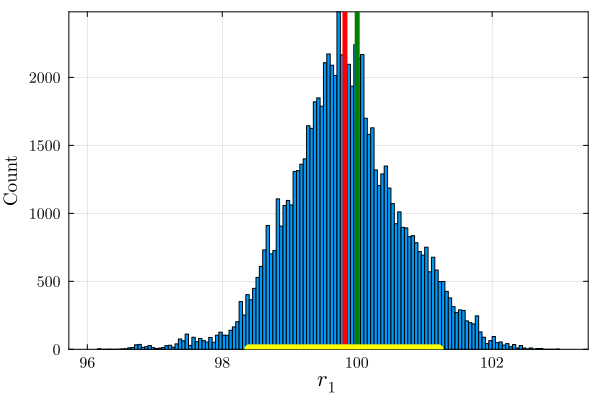

In [5]:
alpha_percentile_05 = quantile(vec(alpha_list), 0.05)
alpha_percentile_95 = quantile(vec(alpha_list), 0.95)

pha = histogram(alpha_list[b_in:N_iter], xlabel=L"r_{1}", ylabel = "Count", xguidefontsize=15, yguidefontsize=12,xtickfontsize=10, ytickfontsize=10)
pha = vline!([mean(alpha_list[b_in:N_iter])], color = :red, linewidth = 5)
pha = vline!([r1], color = :green, linewidth = 5)
pha = plot!([alpha_percentile_05; alpha_percentile_95], [0; 0], lw=10, lc=:yellow, legend=false)

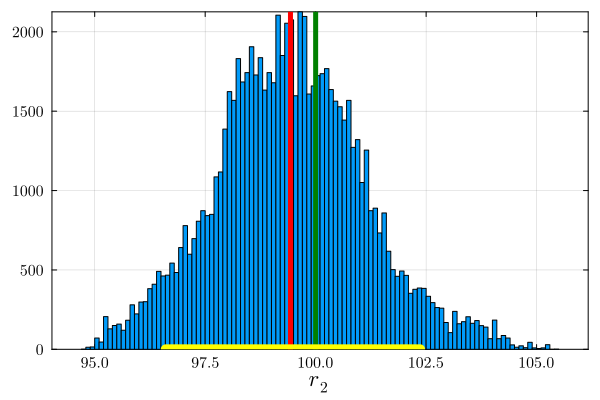

In [6]:
delta_percentile_05 = quantile(vec(delta_list[b_in:N_iter]), 0.05)
delta_percentile_95 = quantile(vec(delta_list[b_in:N_iter]), 0.95)

phd = histogram(delta_list[b_in:N_iter], xlabel=L"r_{2}", xguidefontsize=15, yguidefontsize=12,xtickfontsize=10, ytickfontsize=10)
phd = vline!([mean(delta_list[b_in:N_iter])], color = :red, linewidth = 5)
phd = vline!([r2], color = :green, linewidth = 5)
phd = plot!([delta_percentile_05; delta_percentile_95], [0; 0], lw=10, lc=:yellow, legend=false)

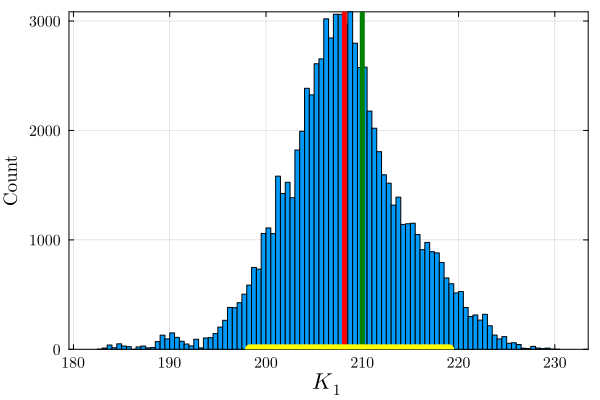

In [7]:
K1_percentile_05 = quantile(vec(K1_list[b_in:N_iter]), 0.05)
K1_percentile_95 = quantile(vec(K1_list[b_in:N_iter]), 0.95)

phK1 = histogram(K1_list[b_in:N_iter], xlabel=L"K_{1}", ylabel = "Count", xguidefontsize=15, yguidefontsize=12,xtickfontsize=10, ytickfontsize=10)
phK1 = vline!([mean(K1_list[b_in:N_iter])], color = :red, linewidth = 5)
phK1 = vline!([K1], color = :green, linewidth = 5)
phK1 = plot!([K1_percentile_05; K1_percentile_95], [0; 0], lw=10, lc=:yellow, legend=false)

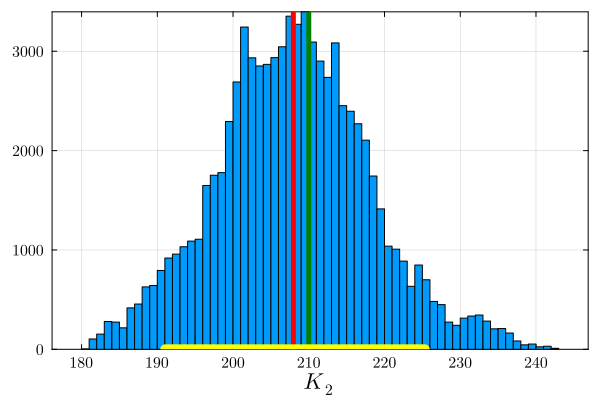

In [8]:
K2_percentile_05 = quantile(vec(K2_list[b_in:N_iter]), 0.05)
K2_percentile_95 = quantile(vec(K2_list[b_in:N_iter]), 0.95)

phK2 = histogram(K2_list[b_in:N_iter], xlabel=L"K_{2}", xguidefontsize=15, yguidefontsize=12,xtickfontsize=10, ytickfontsize=10)
phK2 = vline!([mean(K2_list[b_in:N_iter])], color = :red, linewidth = 5)
phK2 = vline!([K2], color = :green, linewidth = 5)
phK2 = plot!([K2_percentile_05; K2_percentile_95], [0; 0], lw=10, lc=:yellow, legend=false)

Final plot containing the MCMC results.

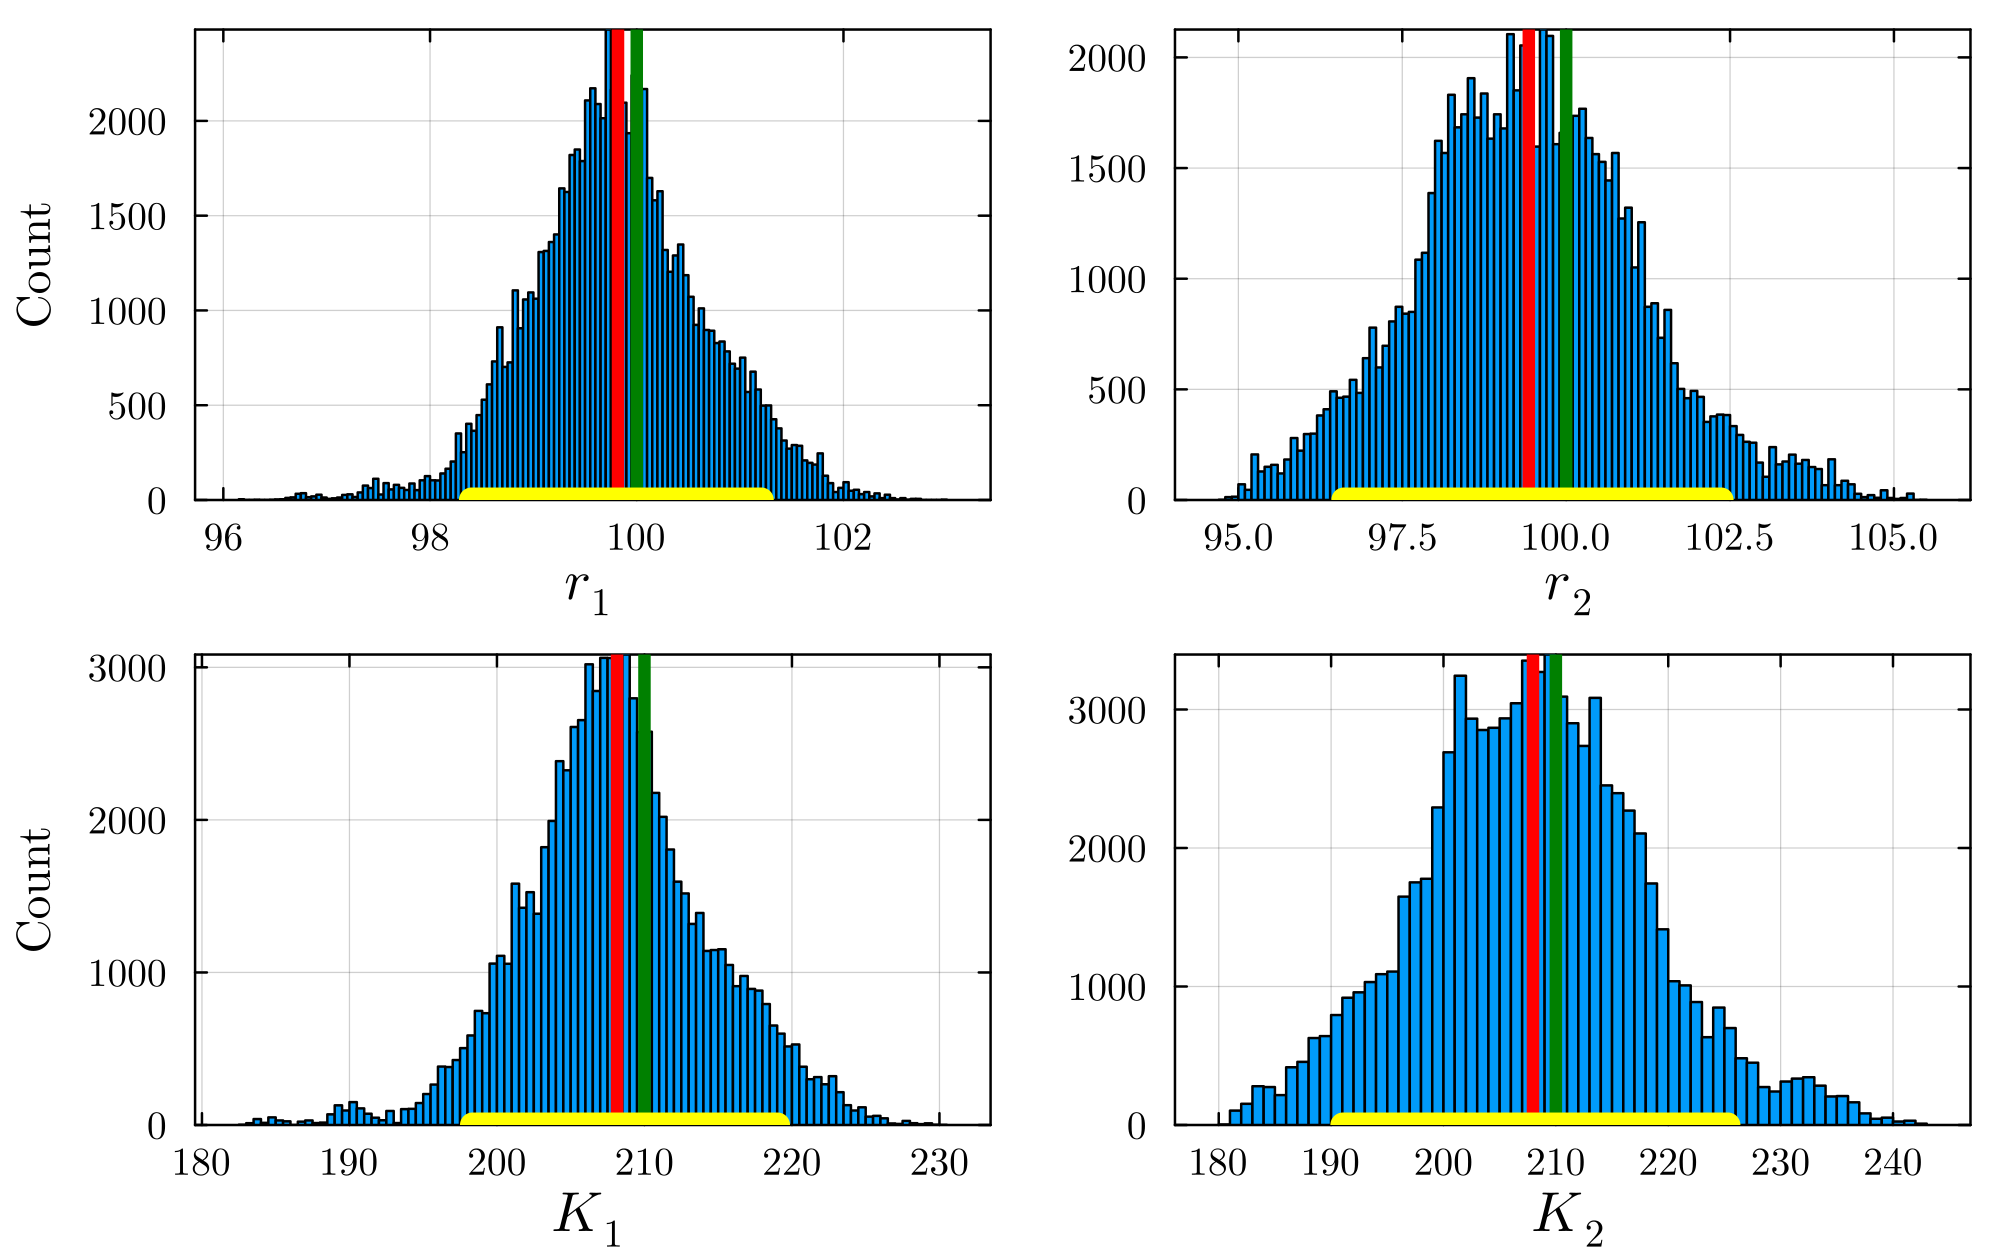

In [10]:
MCMC_plot = plot(pha, phd, phK1, phK2, layout = grid(2, 2), size = (800, 500), dpi = 250, left_margin=3mm) 